In [9]:
import concurrent
import os
import re
import nbformat
import pandas as pd
import papermill as pm
from pathlib import Path
import os
import nbformat
import re
from bs4 import BeautifulSoup

from hireverse.utils.utils import BASE_DIR


def get_output_notebook_path(label):
    return os.path.join(BASE_DIR, "outputs", f"{label}_runner_output.ipynb")


def execute_notebook(label, drop_some_facial_features=False):
    input_notebook_path = os.path.join(
        BASE_DIR, "src", "hireverse", "pipelines", "model_creator.ipynb"
    )
    ouput_path = get_output_notebook_path(label)
    pm.execute_notebook(
        input_notebook_path,
        ouput_path,
        parameters=dict(target_column=label),
        progress_bar=True,
    )
    return get_scores_from__output_jupyter(label)


def get_scores_from__output_jupyter(label):
    notebook_path = get_output_notebook_path(label)
    with open(notebook_path, "r") as notebook_file:
        notebook_content = nbformat.read(notebook_file, as_version=4)

    avg_r2_score = None
    avg_pearson_score = None

    for cell in notebook_content["cells"]:
        if cell["cell_type"] == "code":
            for output in cell.get("outputs", []):
                output_text = ""
                # Handle "stream"/"execute_result"/other outputs
                if "data" in output:
                    for mime_type in ["text/plain", "text/html", "text/latex"]:
                        if mime_type in output.data:
                            if mime_type == "text/html":
                                soup = BeautifulSoup(
                                    output.data[mime_type], "html.parser"
                                )
                                output_text += soup.get_text(separator=" ").strip()
                            else:
                                output_text += output.data[mime_type].strip()
                            output_text += "\n"
                elif "text" in output:
                    output_text = output["text"].strip()

                # Match scores
                r2_match = re.search(
                    r"Mean R² Score[:\s]*(-?[0-9.]+)(\s*\(±[0-9.]+\))?",
                    output_text,
                    re.IGNORECASE,
                )
                pearson_match = re.search(
                    r"Mean Pearson Correlation[:\s]*([0-9.]+)(\s*\(±[0-9.]+\))?",
                    output_text,
                    re.IGNORECASE,
                )

                if r2_match and not avg_r2_score:
                    avg_r2_score = r2_match.group(1)
                if pearson_match and not avg_pearson_score:
                    avg_pearson_score = pearson_match.group(1)

    return {
        "label": label,
        "avg_r2_score": avg_r2_score,
        "avg_pearson_score": avg_pearson_score,
    }


file_path = os.path.join(
    BASE_DIR, "data", "external", "turker_scores_full_interview.csv"
)
df = pd.read_csv(file_path)
labels = df.columns[3:].tolist()
list = []
for label in labels:
    list.append(execute_notebook(label))
    sorted_data = sorted(list, key=lambda x: x["avg_pearson_score"], reverse=True)

Executing: 100%|██████████| 23/23 [00:23<00:00,  1.03s/cell]


In [10]:
print(list)

[{'label': 'RecommendHiring', 'avg_r2_score': '0.11', 'avg_pearson_score': '0.49'}, {'label': 'Colleague', 'avg_r2_score': '0.10', 'avg_pearson_score': '0.47'}, {'label': 'Engaged', 'avg_r2_score': '0.05', 'avg_pearson_score': '0.46'}, {'label': 'Excited', 'avg_r2_score': '0.25', 'avg_pearson_score': '0.60'}, {'label': 'EyeContact', 'avg_r2_score': '-0.24', 'avg_pearson_score': '0.10'}, {'label': 'Smiled', 'avg_r2_score': '0.32', 'avg_pearson_score': '0.64'}, {'label': 'SpeakingRate', 'avg_r2_score': '-0.15', 'avg_pearson_score': '0.30'}, {'label': 'NoFillers', 'avg_r2_score': '-0.03', 'avg_pearson_score': '0.38'}, {'label': 'Friendly', 'avg_r2_score': '0.31', 'avg_pearson_score': '0.63'}, {'label': 'Paused', 'avg_r2_score': '0.02', 'avg_pearson_score': '0.39'}, {'label': 'EngagingTone', 'avg_r2_score': '0.25', 'avg_pearson_score': '0.61'}, {'label': 'StructuredAnswers', 'avg_r2_score': '0.09', 'avg_pearson_score': '0.45'}, {'label': 'Calm', 'avg_r2_score': '-0.21', 'avg_pearson_score'

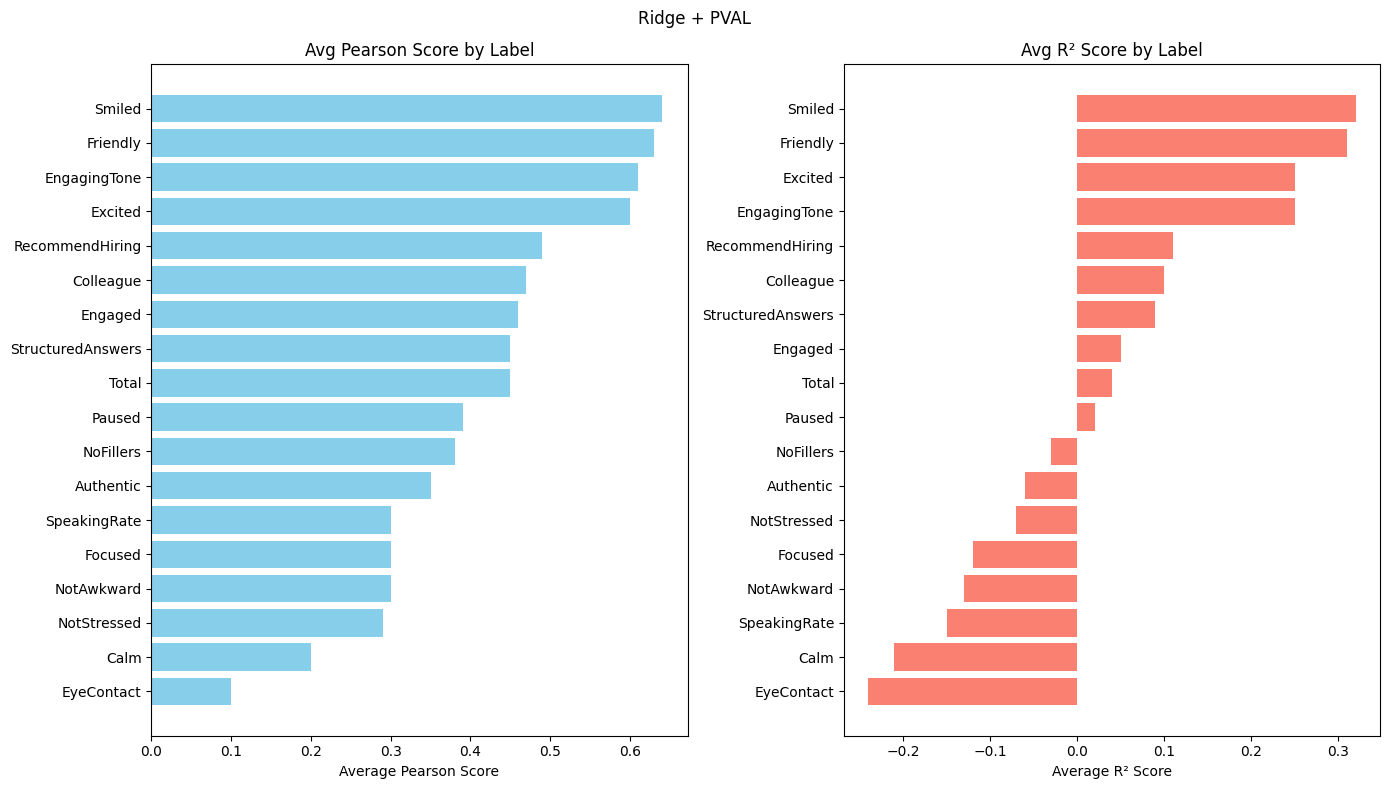

In [11]:
from matplotlib import pyplot as plt
import numpy as np

# --------- Pearson Plot Data (Sorted) ---------
pearson_sorted = sorted(
    [d for d in list if d["avg_pearson_score"] is not None],
    key=lambda x: float(x["avg_pearson_score"]),
    reverse=True
)
pearson_labels, pearson_scores = zip(*[
    (d["label"], float(d["avg_pearson_score"])) for d in pearson_sorted
])

# --------- R² Plot Data (Sorted) ---------
r2_sorted = sorted(
    [d for d in list if d["avg_r2_score"] is not None],
    key=lambda x: float(x["avg_r2_score"]),
    reverse=True
)
r2_labels, r2_scores = zip(*[
    (d["label"], float(d["avg_r2_score"])) for d in r2_sorted
])

# --------- Plotting ---------
fig, axs = plt.subplots(1, 2, figsize=(14, 8), sharey=False)

# Pearson subplot
axs[0].barh(pearson_labels[::-1], pearson_scores[::-1], color='skyblue')
axs[0].set_xlabel('Average Pearson Score')
axs[0].set_title('Avg Pearson Score by Label')

# R² subplot
axs[1].barh(r2_labels[::-1], r2_scores[::-1], color='salmon')
axs[1].set_xlabel('Average R² Score')
axs[1].set_title('Avg R² Score by Label')

fig.suptitle("Ridge + PVAL")
plt.tight_layout()
plt.show()

In [12]:

# list = [
#     {"label": "Excited", "avg_r2_score": "0.34", "avg_pearson_score": "0.64"},
#     {"label": "EngagingTone", "avg_r2_score": "0.30", "avg_pearson_score": "0.62"},
#     {"label": "Smiled", "avg_r2_score": "0.28", "avg_pearson_score": "0.60"},
#     {"label": "Friendly", "avg_r2_score": "0.20", "avg_pearson_score": "0.55"},
#     {"label": "RecommendHiring", "avg_r2_score": "0.20", "avg_pearson_score": "0.54"},
#     {"label": "StructuredAnswers", "avg_r2_score": "0.23", "avg_pearson_score": "0.54"},
#     {"label": "Engaged", "avg_r2_score": "0.14", "avg_pearson_score": "0.50"},
#     {"label": "Total", "avg_r2_score": "0.15", "avg_pearson_score": "0.50"},
#     {"label": "NoFillers", "avg_r2_score": "0.15", "avg_pearson_score": "0.48"},
#     {"label": "Colleague", "avg_r2_score": "0.14", "avg_pearson_score": "0.47"},
#     {"label": "Paused", "avg_r2_score": "0.15", "avg_pearson_score": "0.47"},
#     {"label": "Calm", "avg_r2_score": "0.09", "avg_pearson_score": "0.43"},
#     {"label": "NotAwkward", "avg_r2_score": "0.07", "avg_pearson_score": "0.43"},
#     {"label": "SpeakingRate", "avg_r2_score": "0.08", "avg_pearson_score": "0.42"},
#     {"label": "Focused", "avg_r2_score": "0.03", "avg_pearson_score": "0.37"},
#     {"label": "Authentic", "avg_r2_score": "0.00", "avg_pearson_score": "0.34"},
#     {"label": "NotStressed", "avg_r2_score": None, "avg_pearson_score": "0.30"},
#     {"label": "EyeContact", "avg_r2_score": None, "avg_pearson_score": "0.28"},
# ]
